## Exploring predictions

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
import gc
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import silence_tensorflow

import experiment_settings
import build_model
import plots
import build_data
import read_landsat
import methods
import methods
import predictions
import read_landsat

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"tensorflow version = {tf.__version__}")  

# tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on
print(tf.config.list_physical_devices('GPU'))

python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2
tensorflow version = 2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# GET SETTINGS
EXP_NAME = "exp1"
REWRITE = True
settings = experiment_settings.get_settings(EXP_NAME)

directory_paths = methods.get_directories()
SAVE_MODEL_DIRECTORY = directory_paths["save_model_dir"]
DATA_DIRECTORY = directory_paths["data_dir"]
FIGURE_DIRECTORY = directory_paths["figures_dir"]
PREDICTIONS_DIRECTORY = directory_paths["predictions_dir"]
LANDSAT_DIRECTORY = directory_paths["landsat_dir"]
MOSAICS_DIRECTORY = directory_paths["mosaics_dir"]

Metal device set to: Apple M1 Max

systemMemory: 64.00 GB
maxCacheSize: 24.00 GB

 --- 2020---
landsat_-6lat_107lon_2020
output region shape = (259, 297)
n_inference = (76923,)
151/151 [==============================] - 43s 285ms/step
33729 33471 106496 106792
-6.897713909111744 -6.202417879203239 107.0014775949706 107.79918156726876
-6.897713909111744 -6.202417879203239 107.0014775949706 107.79918156726876
| 0.00, 0.00, 107.00|
| 0.00,-0.00,-6.20|
| 0.00, 0.00, 1.00|


IndexError: list index out of range

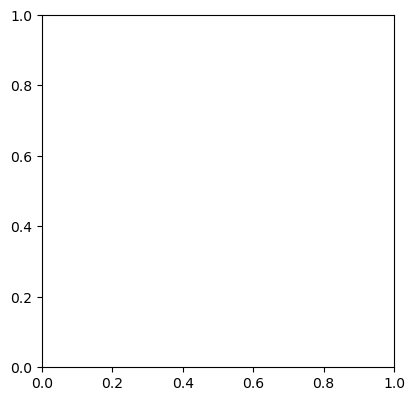

In [4]:
# GET THE DATA
imp.reload(build_data)
imp.reload(read_landsat)
imp.reload(methods)
imp.reload(predictions)

# set and get important settings
settings["batch_size"] = 512
settings["mode"] = "inference"
settings["inference_region"] = (-6.9,-6.2,107,107.8)
(lat_s_bound, 
 lat_n_bound, 
 lon_w_bound, 
 lon_e_bound) = read_landsat.get_landsat_bounds(settings, 
                                                region=settings["inference_region"])

# load the model
model = build_model.get_model(settings)

for year in (2020, 2000, 2005, 2010, 2021, 2022):  # np.arange(2000, 2023):

    print(' --- ' + str(year) + '---')
    settings["inference_years"] = (year, )
    filenames_list = []

    for latfile in np.arange(lat_s_bound + settings["tile_len_deg"], 
                             lat_n_bound + settings["tile_len_deg"], 
                             settings["tile_len_deg"]):
        
        for lonfile in np.arange(lon_w_bound, 
                                 lon_e_bound, 
                                 settings["tile_len_deg"]):

            # CHECK IF LANDSAT FILE EXISTS
            settings["tile"] = (latfile - settings["tile_len_deg"], 
                                latfile, 
                                lonfile, 
                                lonfile + settings["tile_len_deg"])
            landsat_file = read_landsat.get_input_filename(settings["inference_years"], 
                                                           (latfile,), (lonfile,), 
                                                           settings)

            # CHECK IF LANDSAT FILE EXISTS
            if os.path.isfile(LANDSAT_DIRECTORY + landsat_file[0] + ".tif") is False:
                continue

            # CHECK IF PREDICTION FILE ALREADY EXISTS
            predictions_filename = settings["exp_name"] + "_predictions_" + landsat_file[0]
            filenames_list.append(predictions_filename + ".tif")
            if os.path.isfile(PREDICTIONS_DIRECTORY + predictions_filename + ".tif") and REWRITE is False:
                continue
            print(landsat_file[0])
            
            # GET THE SAMPLE TAGS
            tags_inf, __ = build_data.get_tags(settings)
            if len(tags_inf[0]) == 0:
                continue
            
            # BUILD THE DATA AND MAKE THE PREDICTIONS
            tfds_inf = build_data.build_tf_dataset(settings, tags_inf, settings["batch_size"])
            tfds_inf = tfds_inf.prefetch(tf.data.AUTOTUNE)

            # MAKE PREDICTIONS and SAVE AS TIF
            hfi_predict, hfi_labels, latlon_bounds = predictions.make_predictions(settings, model, tfds_inf, tags_inf)
            meta_data = predictions.save_predictions_tif(hfi_predict, 
                                                         PREDICTIONS_DIRECTORY + predictions_filename + ".tif",
                                                         latlon_bounds=latlon_bounds)
            filenames_list.append(predictions_filename + ".tif")

            # PLOT THE RESULTS
            lat_s, lat_n, lon_w, lon_e = latlon_bounds
            plt.figure(figsize=(10,5))
            plt.subplot(1,2,1)
            plots.plot_hfi_tile(hfi_predict, [lon_w, lon_e, lat_s, lat_n])
            plt.title('mlHFI Predictions for ' + str(settings["inference_years"][0]))
            plt.clim(0,100)

            plt.subplot(1,2,2)
            plots.plot_hfi_tile(hfi_labels, [lon_w, lon_e, lat_s, lat_n])
            plt.title('HFI Labels for ' + str(settings["inference_years"][0]))
            plt.clim(0,100)

            # plt.savefig(FIGURE_DIRECTORY + predictions_filename + ".png")
            # plt.close()


    # TILE THE PREDICTIONS TOGETHER
    error('here')
    mosaic_filename = (MOSAICS_DIRECTORY + settings["exp_name"] 
                        + "_" + str(settings["inference_years"][0]) 
                        + "_mlhfi_mosaic.tif")
    mosaic, mosaic_trans = predictions.create_mosaic(filenames_list)
    meta_data = predictions.save_predictions_tif(mosaic, mosaic_filename, trans=mosaic_trans)
    print("mosaic saved.")

In [22]:
imp.reload(predictions)
meta_data = predictions.save_predictions_tif(hfi_predict, 
                                                         PREDICTIONS_DIRECTORY + predictions_filename + ".tif",
                                                         latlon_bounds=latlon_bounds)

-6.897713909111744 -6.202417879203239 107.0014775949706 107.79918156726876
| 0.00, 0.00, 107.00|
| 0.00, 0.00,-6.20|
| 0.00, 0.00, 1.00|


In [ ]:
mosaic_filename = (MOSAICS_DIRECTORY + settings["exp_name"] 
                    + "_" + str(settings["inference_years"][0]) 
                    + "_mlhfi_mosaic.tif")
mosaic, mosaic_trans = predictions.create_mosaic(filenames_list)
meta_data = predictions.save_predictions_tif(mosaic, mosaic_filename, trans=mosaic_trans)
print("mosaic saved.")

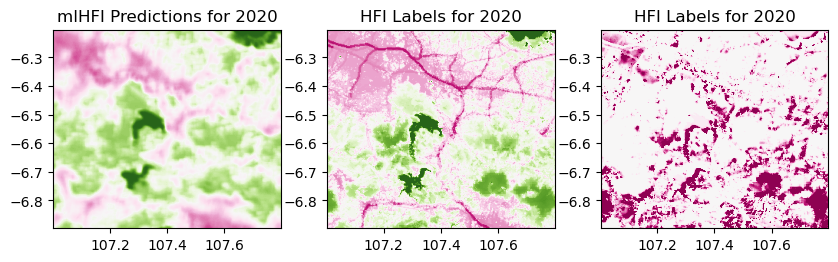

In [23]:
imp.reload(plots)
lat_s, lat_n, lon_w, lon_e = latlon_bounds
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plots.plot_hfi_tile(hfi_predict, [lon_w, lon_e, lat_s, lat_n])
plt.title('mlHFI Predictions for ' + str(settings["inference_years"][0]))
plt.clim(0,100)


plt.subplot(1,3,2)
plots.plot_hfi_tile(hfi_labels, [lon_w, lon_e, lat_s, lat_n])
plt.title('HFI Labels for ' + str(settings["inference_years"][0]))
plt.clim(0,100)


plt.subplot(1,3,3)
d = hfi_predict - hfi_labels
d[d>100] = 0.
plots.plot_hfi_tile(d, [lon_w, lon_e, lat_s, lat_n])
plt.title('HFI Labels for ' + str(settings["inference_years"][0]))
plt.clim(-25,25)


In [18]:
d

array([[  3,   2,   2, ...,   2,   2,   2],
       [  3,   2,   2, ...,   1,   1, 221],
       [  3,   2,   2, ...,   2,   2,   2],
       ...,
       [239, 239,   4, ...,   8,  21,  16],
       [237,   3, 250, ...,   9,  19,  13],
       [238, 250, 236, ..., 255,  11,  13]], dtype=uint8)

In [ ]:
# import rasterio
# from rasterio.windows import Window
# imp.reload(methods)
# filename_mask = DATA_DIRECTORY + "hii_coastal_buffer_mask.tif"

# lat1, lat0, lon0, lon1 = latlon_bounds
# print(latlon_bounds)

# with rasterio.open(filename_mask) as buffer_mask:
#     buffer_meta = buffer_mask.meta
#     ilat0, ilat1, ilon0, ilon1 = methods.get_tile_indices(buffer_mask, (lat0, lat1, lon0, lon1))
#     window = Window.from_slices((ilat0, ilat1 + 1), (ilon0, ilon1 + 1))
#     print(window)
#     # x = buffer_mask.read(1,window)
# display(buffer_meta)